# Reading in ERA-5 Data and Comparing with GridRad

## Overview

In the last notebook, we read in and analyzed radar reflectivity and azimuthal shear data from GridRad-Severe over the Turin, NY supercell on August 7th, 2023. In this follow-up notebook, we will look at a couple more variables centered around this severe thunderstorm event, this time using the ERA-5 hourly single-level data, which is part of the fifth-generation ECMWF reanalysis provided by Destination Earth's Earth Data Hub. We will then compare these graphs to the GridRad data plotted in the previous notebook and see if they match up with actual observations. 

1. Prerequisites
2. Imports
3. Content
4. Summary
5. Conclusions
6. Resources and References

## Prerequisites 

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Numpy](https://foundations.projectpythia.org/core/numpy/) | Necessary | |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of Datetime](https://foundations.projectpythia.org/core/datetime/) | Helpful | Using times and calendars in Python |
| [Using MetPy](https://unidata.github.io/MetPy/latest/tutorials/unit_tutorial.html) | Helpful | Working with Units and Making Conversions |
| [Understanding of Xarray](https://foundations.projectpythia.org/core/xarray/) | Helpful | Analysis of gridded datasets |
| [Understanding of Matplotlib](https://foundations.projectpythia.org/core/matplotlib/) | Helpful | Creating plots in Python |

- **Time to learn**: About 1 hour (10 minutes per subsection)

## Imports

As always, we will start off my importing any relevant datasets we will need in this notebook. We use xarray, numpy, cartopy and matplotlib like in the last notebook, but in addition, we will need the datetime library to read in specific dates and make a time string, and metpy to make unit conversions and calculations. 

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

## Content #1: Importing ERA5 Pressure Level Data 

We will first use xarray to access the ERA5 hourly data on pressure levels, accessible via an Analysis Ready, Cloud Optimized (ARCO) format on Destination Earth's Earth Data Hub. We will point the object to the Zarr engine: 

In [2]:
file_path = '/nfs/mulholland_lab/acolgate/Research/2018/2018/nexrad_3d_v4_2_20180505T012000Z.nc' 
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 79MB
Dimensions:                    (Sweep: 417, Altitude: 29, Latitude: 576,
                                Longitude: 576, Index: 1000794, time: 1)
Coordinates:
  * Altitude                   (Altitude) float64 232B 0.5 1.0 1.5 ... 21.0 22.0
  * Latitude                   (Latitude) float64 5kB 36.01 36.03 ... 47.99
  * Longitude                  (Longitude) float64 5kB 278.0 278.0 ... 290.0
  * time                       (time) datetime64[ns] 8B 2018-05-05T01:20:00
Dimensions without coordinates: Sweep, Index
Data variables: (12/18)
    sweeps_merged              (Sweep) |S29 12kB ...
    Nradobs                    (Altitude, Latitude, Longitude) int8 10MB ...
    Nradecho                   (Altitude, Latitude, Longitude) int8 10MB ...
    index                      (Index) int32 4MB ...
    Reflectivity               (Index) float32 4MB ...
    wReflectivity              (Index) float32 4MB ...
    ...                         ...
    DifferentialReflectivity   (Index) float32 4MB ...
    wDifferentialReflectivity  (Index) float32 4MB ...
    DifferentialPhase          (Index) float32 4MB ...
    wDifferentialPhase         (Index) float32 4MB ...
    CorrelationCoefficient     (Index) float32 4MB ...
    wCorrelationCoefficient    (Index) float32 4MB ...
Attributes: (12/16)
    Name:                   GridRad
    Description:            Three-dimensional gridded NEXRAD radar reflectivi...
    Analysis_time:          2018-05-05 01:20:00Z
    Analysis_time_window:   all azimuth scans (elevation angles) with central...
    Algorithm_version:      v4_2
    Algorithm_description:  Space and time binning weighted by distances from...
    ...                     ...
    Storage_scheme:         netCDF-4, sparse
    Data_source:            Amazon Web Services
    Data_source_URL:        https://www.ncdc.noaa.gov/data-access/radar-data/...
    Authors:                Cameron R. Homeyer, School of Meteorology, Univer...
    Project_sponsor:        National Oceanic and Atmospheric Administration, ...
    Project_name:           0-3 Hour Tornado Prediction Using the Warn on For...

Next, let's specify the region and time of interest. For this, we will use the same date/time we used in Notebook 1 to analyze the same storm and environment. 

In [3]:
lon_vals = ds['Longitude'].values
lat_vals = ds['Latitude'].values
alt_vals = ds['Altitude'].values

nlon, nlat, nalt = len(lon_vals), len(lat_vals), len(alt_vals)

azshear_grid = np.full((nalt, nlat, nlon), np.nan, dtype=np.float32)

index = ds['index'].values
azshear = ds['AzShear'].values

k = index // (nlat * nlon)
j = (index % (nlat * nlon)) // nlon
i = index % nlon

azshear_grid[k, j, i] = azshear

colmax_azshear = np.nanmax(azshear_grid, axis=0)
colmax_azshear = np.squeeze(colmax_azshear)

/tmp/ipykernel_1586709/622174279.py:18: RuntimeWarning: All-NaN slice encountered
  colmax_azshear = np.nanmax(azshear_grid, axis=0)


## Further examine the dataset: 

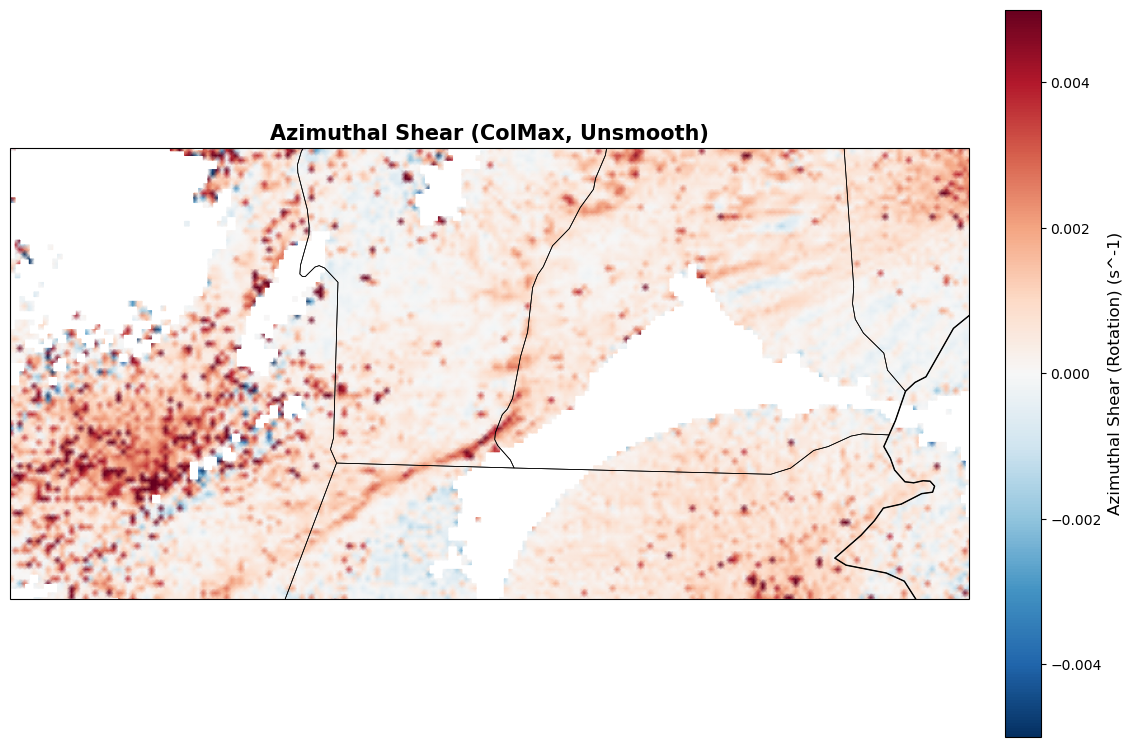

In [4]:
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

pcm = ax.pcolormesh(
    lon_grid, lat_grid, colmax_azshear,
    cmap='RdBu_r',          
    vmin=-0.005, vmax=0.005,  
    shading='gouraud',     
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')

extent = [-70.45, -74.7, 42.15, 44.15]
ax.set_extent(extent, crs=ccrs.PlateCarree())

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label("Azimuthal Shear (Rotation) (s^-1)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Azimuthal Shear (ColMax, Unsmooth)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

The first variable I thought would be helpful to analyze would be the vertical velocity. I retrieved the variable from the DataArray, and then further examined it. 

In [5]:
file_path2 = '/nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T220500Z.nc' 
ds2 = xr.open_dataset(file_path2)
print(ds2)

<xarray.Dataset> Size: 79MB
Dimensions:                    (Sweep: 733, Altitude: 29, Latitude: 624,
                                Longitude: 576, Index: 972593, time: 1)
Coordinates:
  * Altitude                   (Altitude) float64 232B 0.5 1.0 1.5 ... 21.0 22.0
  * Latitude                   (Latitude) float64 5kB 33.01 33.03 ... 45.99
  * Longitude                  (Longitude) float64 5kB 274.0 274.0 ... 286.0
  * time                       (time) datetime64[ns] 8B 2021-07-29T22:05:00
Dimensions without coordinates: Sweep, Index
Data variables: (12/18)
    sweeps_merged              (Sweep) |S29 21kB ...
    Nradobs                    (Altitude, Latitude, Longitude) int8 10MB ...
    Nradecho                   (Altitude, Latitude, Longitude) int8 10MB ...
    index                      (Index) int32 4MB ...
    Reflectivity               (Index) float32 4MB ...
    wReflectivity              (Index) float32 4MB ...
    ...                         ...
    DifferentialReflectivity 

## Performing unit conversions

It can be seen that the data variable is in units of Pa/s. It would be better to convert this into hectopascals (hPa) since that is more commonly measured on meteorological maps. This is where MetPy comes in handy, as we can use a unit conversion method on the DataArray to convert it into hPa/s:

In [6]:
lon_vals2 = ds2['Longitude'].values
lat_vals2 = ds2['Latitude'].values
alt_vals2 = ds2['Altitude'].values

nlon2, nlat2, nalt2 = len(lon_vals2), len(lat_vals2), len(alt_vals2)

azshear_grid2 = np.full((nalt2, nlat2, nlon2), np.nan, dtype=np.float32)

index2 = ds2['index'].values
azshear2 = ds2['AzShear'].values

k2 = index2 // (nlat2 * nlon2)
j2 = (index2 % (nlat2 * nlon2)) // nlon2
i2 = index2 % nlon2

azshear_grid2[k2, j2, i2] = azshear2

colmax_az_shear = np.nanmax(azshear_grid2, axis=0)
colmax_az_shear = np.squeeze(colmax_az_shear)

/tmp/ipykernel_1586709/1998403774.py:18: RuntimeWarning: All-NaN slice encountered
  colmax_az_shear = np.nanmax(azshear_grid2, axis=0)


Let's look at the updated data values:

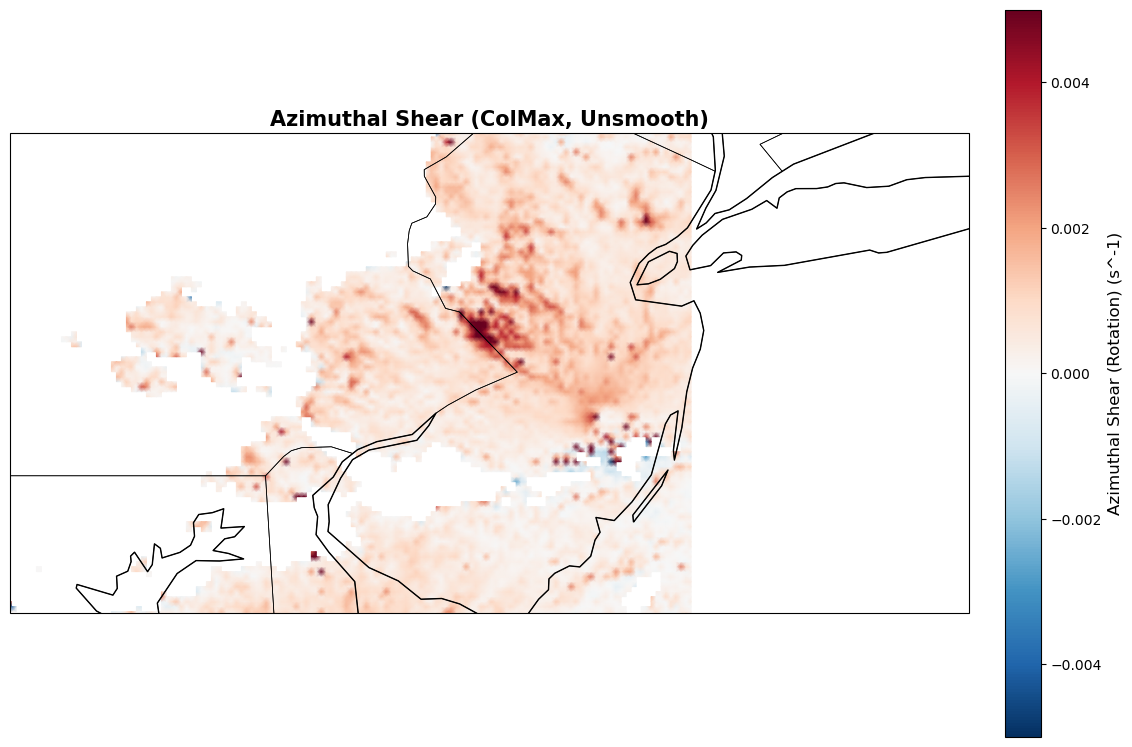

In [7]:
lon_grid, lat_grid = np.meshgrid(lon_vals2, lat_vals2)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

pcm = ax.pcolormesh(
    lon_grid, lat_grid, colmax_az_shear,
    cmap='RdBu_r',          
    vmin=-0.005, vmax=0.005,  
    shading='gouraud',     
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')

extent = [-72.85, -76.85, 39.15, 41.15]
ax.set_extent(extent, crs=ccrs.PlateCarree())

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label("Azimuthal Shear (Rotation) (s^-1)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Azimuthal Shear (ColMax, Unsmooth)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

In [8]:
lon_vals3 = ds['Longitude'].values
lat_vals3 = ds['Latitude'].values
alt_vals3 = ds['Altitude'].values

nlon3, nlat3, nalt3 = len(lon_vals3), len(lat_vals3), len(alt_vals3)

coeff_grid = np.full((nalt3, nlat3, nlon3), np.nan, dtype=np.float32)

index3 = ds['index'].values
coeff = ds['CorrelationCoefficient'].values

k3 = index3 // (nlat3 * nlon3)
j3 = (index3 % (nlat3 * nlon3)) // nlon3
i3 = index3 % nlon3

coeff_grid[k3, j3, i3] = coeff

colmax_coeff = np.nanmax(coeff_grid, axis=0)
colmax_coeff = np.squeeze(colmax_coeff)

/tmp/ipykernel_1586709/2293036275.py:18: RuntimeWarning: All-NaN slice encountered
  colmax_coeff = np.nanmax(coeff_grid, axis=0)


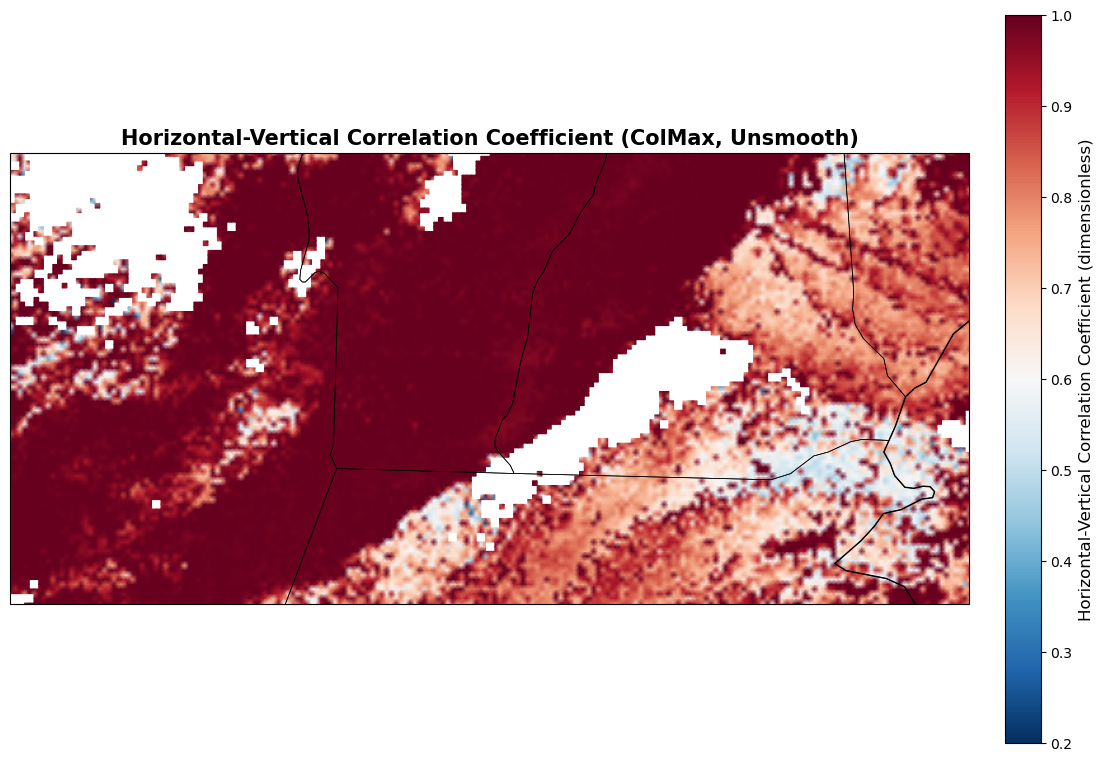

In [9]:
lon_grid3, lat_grid3 = np.meshgrid(lon_vals3, lat_vals3)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

pcm = ax.pcolormesh(
    lon_grid3, lat_grid3, colmax_coeff,
    cmap='RdBu_r',          
    vmin=0.2, vmax=1.0,  
    shading='gouraud',     
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')

extent = [-70.45, -74.7, 42.15, 44.15]
ax.set_extent(extent, crs=ccrs.PlateCarree())

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label("Horizontal-Vertical Correlation Coefficient (dimensionless)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Horizontal-Vertical Correlation Coefficient (ColMax, Unsmooth)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

In [10]:
lon_vals4 = ds2['Longitude'].values
lat_vals4 = ds2['Latitude'].values
alt_vals4 = ds2['Altitude'].values

nlon4, nlat4, nalt4 = len(lon_vals4), len(lat_vals4), len(alt_vals4)

coeff_grid2 = np.full((nalt4, nlat4, nlon4), np.nan, dtype=np.float32)

index4 = ds2['index'].values
coeff2 = ds2['CorrelationCoefficient'].values

k4 = index4 // (nlat4 * nlon4)
j4 = (index4 % (nlat4 * nlon4)) // nlon4
i4 = index4 % nlon4

coeff_grid2[k4, j4, i4] = coeff2

colmax_coeff2 = np.nanmax(coeff_grid2, axis=0)
colmax_coeff2 = np.squeeze(colmax_coeff2)

/tmp/ipykernel_1586709/608759967.py:18: RuntimeWarning: All-NaN slice encountered
  colmax_coeff2 = np.nanmax(coeff_grid2, axis=0)


Next, we need to set a specified pressure level for this data variable. We will select 700 hPa since that is a common atmospheric level in the mid-troposphere where many weather processes occur. Also, since we are making a 2D map from 3D data, we need to convert the data variable into 2-D dimensions. We do this by using xarray's .sel function. 

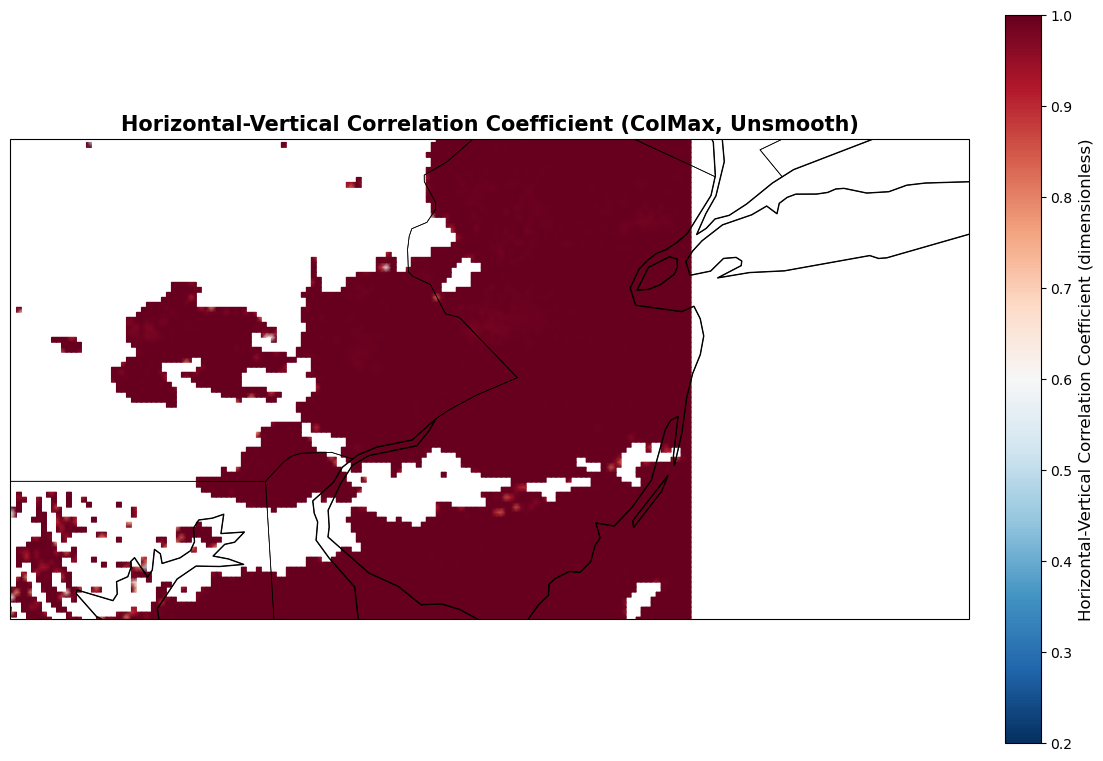

In [11]:
lon_grid4, lat_grid4 = np.meshgrid(lon_vals4, lat_vals4)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 10))

pcm = ax.pcolormesh(
    lon_grid4, lat_grid4, colmax_coeff2,
    cmap='RdBu_r',          
    vmin=0.2, vmax=1.0,  
    shading='gouraud',     
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.7)
ax.coastlines(resolution='50m')

extent = [-72.85, -76.85, 39.15, 41.15]
ax.set_extent(extent, crs=ccrs.PlateCarree())

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label("Horizontal-Vertical Correlation Coefficient (dimensionless)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Horizontal-Vertical Correlation Coefficient (ColMax, Unsmooth)", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

In this graph, the negative (blue) values of vertical velocity represent upward motion and rising air, and the positive (red) values indicate downward motion and sinking air. It can be seen that the areas of negative values match up with where severe thunderstorms were currently located at this time, such as around the Turin, NY area as well as farther southwest where there were other thunderstorms moving through, as there was rapid upward motion over these areas. On the other hand, the red shadings are located over areas where there was not much precpitation, or subsidence, so this graph makes sense and matches up with observations. 

In [14]:
import glob
from matplotlib.animation import FuncAnimation, FFMpegWriter

def decode_gridrad_azshear(ds2):
    """
    Decode sparse GridRad reflectivity (v4.2) to full 3D reflectivity array.
    Returns array with shape:
        (Altitude, Latitude, Longitude)
    """

    nz = ds2["Altitude"].size
    ny = ds2["Latitude"].size
    nx = ds2["Longitude"].size

    # Initialize full grid with NaN
    Z = np.full((nz, ny, nx), np.nan, dtype=np.float32)

    # Sparse arrays
    azshear = ds2["AzShear"].values   # (Index,)
    idx  = ds2["index"].values.astype(np.int64)

    plane_size = ny * nx
    
    alt = idx // plane_size
    rem = idx % plane_size
    lat = rem // nx
    lon = rem % nx

    # Fill grid
    Z[alt, lat, lon] = azshear

    return Z

In [16]:
nc_files2 = sorted(glob.glob("/nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T*.nc"))

colmax_list = []
times = []

print(f"Found {len(nc_files2)} GridRad files")

for f in nc_files2:
    print("Processing:", f)
    ds = xr.open_dataset(f)

    # Decode sparse reflectivity
    Z_az = decode_gridrad_azshear(ds)

    # Column-max reflectivity
    colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)
    colmax_list.append(colmax)

    # Store timestamp
    times.append(str(ds["time"].values[0]))

# Stack into array (Time, Lat, Lon)
colmax_array = np.stack(colmax_list)

# Coordinates
lats = ds2["Latitude"].values
lons = ds2["Longitude"].values
lon_grid, lat_grid = np.meshgrid(lons, lats)

Found 5 GridRad files
Processing: /nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T215500Z.nc


/tmp/ipykernel_1586709/4168391651.py:16: RuntimeWarning: All-NaN slice encountered
  colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)


Processing: /nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T220000Z.nc


/tmp/ipykernel_1586709/4168391651.py:16: RuntimeWarning: All-NaN slice encountered
  colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)


Processing: /nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T220500Z.nc


/tmp/ipykernel_1586709/4168391651.py:16: RuntimeWarning: All-NaN slice encountered
  colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)


Processing: /nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T221000Z.nc


/tmp/ipykernel_1586709/4168391651.py:16: RuntimeWarning: All-NaN slice encountered
  colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)


Processing: /nfs/mulholland_lab/acolgate/Research/2021/2021/nexrad_3d_v4_2_20210729T221500Z.nc


/tmp/ipykernel_1586709/4168391651.py:16: RuntimeWarning: All-NaN slice encountered
  colmax = np.nanmax(Z_az, axis=0)   # (Lat, Lon)


In [17]:
fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# First frame
pcm = ax.pcolormesh(
    lon_grid, lat_grid, np.zeros_like(colmax_array[0]),
    cmap="RdBu_r", vmin=-0.005, vmax=0.005,
    shading="gouraud",
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Azimuthal Shear", fontsize=12)

# Map Features
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.7)
ax.add_feature(cfeature.LAKES.with_scale("50m"), edgecolor="black", facecolor="none", linewidth=0.5)
ax.add_feature(cfeature.RIVERS.with_scale("50m"), linewidth=0.3, alpha=0.4)
ax.coastlines(resolution="50m", linewidth=0.7)

# Set your desired extent (modify as needed)
# Example: Upstate NY from your static plot
ax.set_extent([-72.85, -76.85, 39.15, 41.15])

title = ax.set_title("Azimuthal Shear", fontsize=15, weight="bold")

def update(frame):
    pcm.set_array(colmax_array[frame].ravel())
    title.set_text(times[frame])
    return pcm, title


anim = FuncAnimation(
    fig, update,
    frames=len(colmax_array),
    interval=250,
    blit=False
)

plt.close(fig)

from IPython.display import HTML

# Show animation inside notebook, fully interactive (play/pause + scrub bar)
HTML(anim.to_jshtml())

## Content 2: The V-component Wind Data 

Another variable you can look at in this dataset is the V component of the wind. I wanted to look at a slightly bigger lat/lon range for this, so I re-defined the maximum and minimum lat/lon values.

Then, let's read in and inspect the data variable like we did before:

As can be seen, the v-component wind data variable is in units of meters/second (m/s). It is better to convert this into knots (kts), because once again that is a more commonly measured unit for wind in weather maps. Luckily, we can use a simple unit conversion method to do this again. 

We once again need to select a pressure level. Let's use the 850 hPa level this time, where wind flow in weather maps is commonly measured. 

Then we can finally make the plot, using the same setup we used for the vertical velocity, except making sure to modify the lat/lon extent to the new variables we defined, and the modified variable we used to convert the 'v' data variable into a 2D data shape. 

On the graph, the red values represent positive values of the v-component (southerly wind), and the blues represent negative values (northerly wind). The system's warm sector over eastern NY and New England down into the Mid-Atlantic can clearly be made out, as well as the winds turning more northerly behind the cold frontal passage across the Great Lakes into the Ohio Valley. The front was moving through western NY and northwest PA at this time, which explains the lighter red and blue shadings as you go further west. 

## Summary

To conclude this notebook, it can be seen that you can use another dataset like ERA5 to verify the accuracy of the GridRad radar reflecitivy data, as well as other variables. In this notebook, we made graphs of the vertical pressure velocity at 700 hPA and the v-wind component at 850 hPa from the ERA5 Pressure Level Hourly Data, and this seemed to match up with the GR-S radar refl. and AZ shear data in regards to location, as well as real-life observations. 

## Destination Earth ERA5 Data Hub 

[ERA5 Hourly Data](https://earthdatahub.destine.eu/collections/era5/datasets/reanalysis-era5-pressure-levels) 